# Tennis Data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from package import algorithm

current_path = os.getcwd()
data_path = current_path + '\\' + 'data' + '\\' + 'tennis' + '\\' 
image_path = current_path + '\\' + 'image'+ '\\' + 'tennis'+ '\\'

### Data Preprocessing

In [5]:
covariate = ['winner_age', 'loser_age']
df = combined_df = pd.DataFrame()
for file in os.listdir(data_path):
    if 'atp_matches' in file:
        tem = pd.read_csv(data_path+file,)
        tem = tem.drop(tem[tem['score'] == 'W/O'].index)
        tem = tem.dropna(subset=covariate)
        df = pd.concat([df, tem], ignore_index=True)
    else:
        pass

Select suitable matches and players <br>
<span style="font-size: smaller;">
We remove players whose competition times are less than 10 or who have never won.
</span> 

In [6]:
def delete_players(df,d_min):
    players = df[['winner_name','loser_name']]
    counts = pd.Series(players.values.ravel()).value_counts()
    ### d >= d_min
    remain_players = counts[counts>=d_min].index
    ### winner
    remain_players = remain_players[remain_players.isin(df['winner_name'])].tolist()
    n = len(remain_players)
    return remain_players,n
def delete_matches(df,remain_players):
    df = df[df[['winner_name','loser_name']].isin(remain_players).all(axis=1)]
    N = len(df)
    return df,N
def select(df,d_min=10):
    players = df[['winner_name','loser_name']]
    counts = pd.Series(players.values.ravel()).value_counts()
    all_players = counts.index.tolist()
    nn = len(all_players)
    NN = len(df)
    while True:
        print('-'*10)
        print(f'The number of matches: {NN}')
        print(f'The number of players: {nn}')
        remain_players,n = delete_players(df,d_min)
        df,N = delete_matches(df,remain_players)
        if NN == N and nn == n:
            break
        else:
            NN = N
            nn = n
    return df,n,N    
df,n,N = select(df,10)

----------
The number of matches: 145658
The number of players: 4603
----------
The number of matches: 138397
The number of players: 1991
----------
The number of matches: 137392
The number of players: 1856
----------
The number of matches: 137127
The number of players: 1825
----------
The number of matches: 137043
The number of players: 1815
----------
The number of matches: 136989
The number of players: 1809
----------
The number of matches: 136962
The number of players: 1806
----------
The number of matches: 136944
The number of players: 1804
----------
The number of matches: 136935
The number of players: 1803


In [7]:
df.to_csv(data_path+'tennis(preprocessed).csv',index=None)

### Data Analysis

##### Model selection

In [2]:
# read data
df = pd.read_csv(data_path+'tennis(preprocessed).csv')

# players ID
players = df[['winner_name','loser_name']]
counts = pd.Series(players.values.ravel()).value_counts()
playerID = {value: index for index, value in enumerate(counts.index.tolist())}
n = len(playerID)
# matches
name_columns = ['winner_name','loser_name']
Matches = df[name_columns].replace(playerID)
T = np.array(Matches).tolist()
N = len(T)
# age
age_columns = ['winner_age','loser_age']
Age = np.array(df[age_columns])


C:\Users\13299\AppData\Local\Temp\ipykernel_20056\2717211070.py:2: DtypeWarning: Columns (8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path+'tennis(preprocessed).csv')
C:\Users\13299\AppData\Local\Temp\ipykernel_20056\2717211070.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Matches = df[name_columns].replace(playerID)


In [3]:
# kernel
A = [25,30,35]
Lamb = [0.01, 0.03]
parameters = [(a,lamb) for a in A for lamb in Lamb]
gauss_kernel = lambda x,a,lamb: np.exp(-lamb*(x-a)**2)
gauss_kernel_set = lambda x: np.array([gauss_kernel(x,a,lamb) for (a,lamb) in parameters])
cov = [gauss_kernel_set(age).T for age in Age]

BIC criteria

In [4]:
import itertools
from joblib import Parallel, delayed
# BIC
def get_BIC(T,cov,s,N,n):
    X = [x[:,s] for x in cov]
    d = len(s)
    u_plusDC,v_plusDC = algorithm.AM(T,X,n,d,E=1e-3,Eu=1e-8,Ev=1e-12,type = 'pair',detail=True)
    likelihood = algorithm.multi_likelihood(T,X,u_plusDC,v_plusDC)
    BIC = (n-1+d) * np.log(N) - 2*likelihood*N
    return BIC

# get_subset
get_subset = lambda n: [subset for i in range(n + 1)
                         for subset in itertools.combinations(list(range(n)), i)]
subset = get_subset(6)

res = Parallel(n_jobs=7)(delayed(get_BIC)(T,cov,subset[i],N,n) for i in range(len(subset)))
s = (0, 1, 2, 4)
print('selected subset:', s)

KeyboardInterrupt: 

In [4]:
#s = subset[np.argmin(res)]
s = (0, 1, 2, 4)
print('selected subset:', s)

selected subset: (0, 1, 2, 4)


Plot

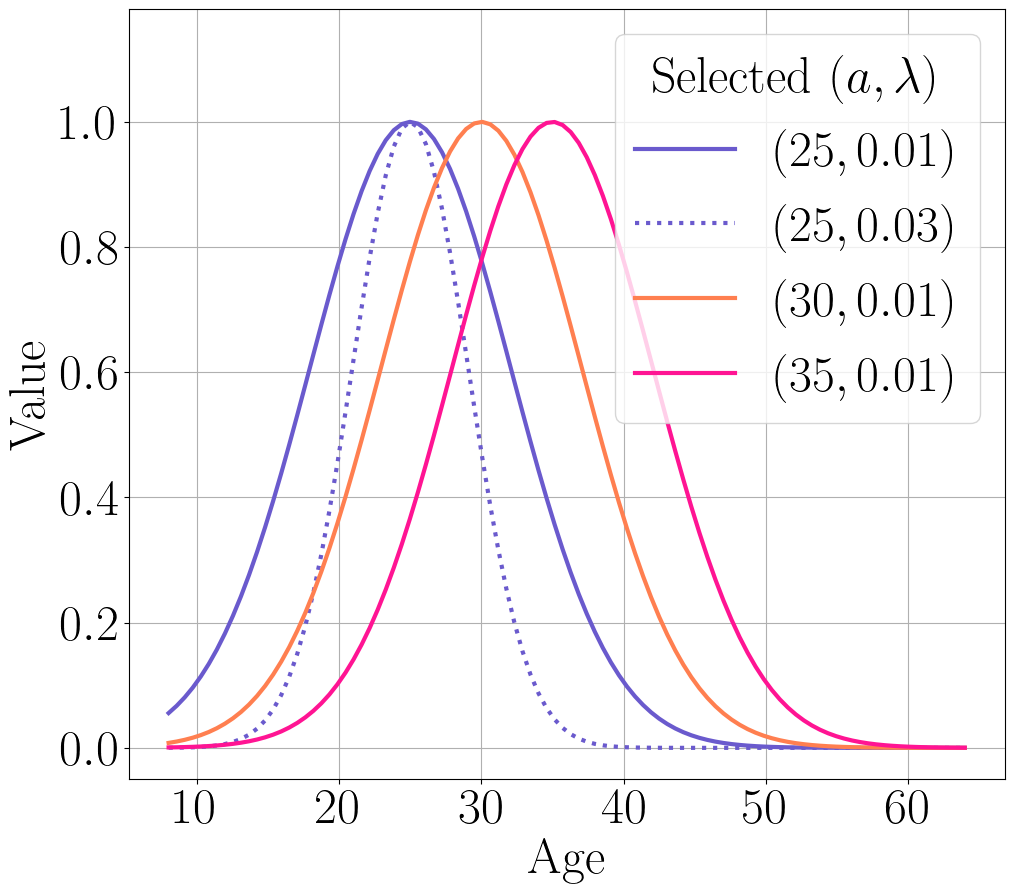

In [5]:
x = np.linspace(8,64,100)

basis_functions_set = [gauss_kernel(x,parameters[ss][0],parameters[ss][1]) for ss in s]
text = ['$(25, 0.01)$', '$(25, 0.03)$', '$(30, 0.01)$', '$(30, 0.03)$', '$(35, 0.01)$', '$(35, 0.03)$']
color = ['slateblue','slateblue','coral','coral','deeppink','deeppink']
linestyle = ['-',':','-',':','-',':']

fig,ax = plt.subplots(figsize=(11.3,10))
for ss in s:
    ax.plot(x, gauss_kernel(x,parameters[ss][0],parameters[ss][1]), 
    color = color[ss], linewidth = 3,linestyle=linestyle[ss], label = text[ss])

sz = 36
ax.set_xlabel('Age', size = sz)
ax.set_ylabel('Value', size = sz)
ax.set_ylim([-0.05, 1.18])
plt.xticks(size = sz)
plt.yticks(size = sz)

rc('text', usetex=True)
rc('font', family='serif')

ax.legend(title='Selected $(a, \lambda)$', prop={'size': sz},\
         title_fontsize=sz, loc='upper right')

plt.grid()

plt.savefig(image_path+'basis.pdf')
plt.show()

##### Fit Model

PlusDC

In [34]:
import numpy as np
def multi_likelihood_three(T,K,u,v = None):
    if len(v) == 0 or v is None:
        d = len(K[0].T)
        v = np.zeros(d)
    else:
        pass
    N = len(T)
    result = 0
    for i, t in enumerate(T):
        R = np.exp(u[t] + K[i] @ v)
        for j in range(3):
            tem = R[j] / sum(R[j:])
            result += np.log(tem)
    return result/N
def multi_likelihood_one(T,K,u,v = None):
    if len(v) == 0 or v is None:
        d = len(K[0].T)
        v = np.zeros(d)
    else:
        pass
    N = len(T)
    result = 0
    for i, t in enumerate(T):
        R = np.exp(u[t] + K[i] @ v)
        tem = R[0] / sum(R)
        result += np.log(tem)
    print(N)
    return result/N

##

def multi_likelihood(T,K,u,v = None):
    if len(v) == 0 or v is None:
        d = len(K[0].T)
        v = np.zeros(d)
    else:
        pass
    N = len(T)
    result = 0
    for i, t in enumerate(T):
        R = np.exp(u[t] + K[i] @ v)
        for j in range(len(t)-1):
            tem = R[j] / sum(R[j:])
            result += np.log(tem)
    return result/N
def multi_Win(T,n):
    W = np.zeros((n))
    for i, t in enumerate(T):
        #print("s:",t[:-1])
        W[t[:-1]] += 1
    return W
def multi_DynamicScore_Win(K,v):
    D_r = []
    for k in K:
        #print("s:",t[:-1])
        tem = np.exp(k@v)
        tem = tem/sum(tem)
        D_r.append(tem)
    return D_r
def multi_updata_R(R,W,D,T,n):
    M = np.zeros(n)
    for i, t in enumerate(T):
        d = D[i]
        tem = d*R[t]
        s1 = [1/sum(tem[i:]) for i in range(len(t)-1)]
        pair_denominator = [d[i]*sum(s1[:i+1]) for i in range(len(t))]
        M[t] += pair_denominator

    R_new = W/M
    R_new /= np.sum(R_new)
    return R_new
def multi_fixv(T,K,v,n,W, E = 1e-6 , I = 50, utr = None, detail = False):
    D = multi_DynamicScore_Win(K, v)
    if utr is None:
        R = np.ones(n)/n
    else:
        R = np.exp(utr)/sum(np.exp(utr))
    i, error = 1, 1
    while error > E and i < I:
        R_new = multi_updata_R(R,W,D,T,n)
        #updata = np.log(R_new / R)
        updata = R_new - R
        error = max(abs((updata)))
        #print(error)
        R = R_new
        i += 1
    if detail:
        print(f'u iterative times: {i}')
    else:
        pass
    u = np.log(R_new)
    u = u - np.mean(u)
    return u
###############
def multi_updata_v(v,u,T,K,d):
    tem = 0
    H = np.zeros((d,d))
    for i, X in enumerate(K):
        coe = np.exp(u[T[i]]+X@v)
        for j in range(len(X)-1):
            x = X[j:]
            c = coe[j:]/sum(coe[j:])
            XX = x.T@c
            tem += X[j] - XX
            D = x.T@np.diag(c)@x
            O = np.outer(XX,XX)
            H += D - O
    H = np.linalg.inv(H)
    updata = H@tem
    return updata
def multi_fixu(T,K,u,d, E=1e-6, I = 1000,vtr = None,detail = False):
    if vtr is None:
        v = np.zeros(d)
    else:
        v = vtr[:]
        pass
    i, error = 1, 1
    l0 = multi_likelihood(T, K, u, v)
    while error > E*1000 and i < I:
        v_updata = multi_updata_v(v,u,T,K,d)
        #print(v_updata)
        v = v + v_updata
        if d == 1:
            error = abs(v_updata)
        else:
            error = sum(abs(v_updata))
        #print(error)
        l1 = multi_likelihood(T, K, u, v)
        """if l1>=l0:
            print(f'True:{l1}')
        else:
            print(f'False:{l1-l0}')"""
        l0 = l1
        i += 1
    if detail:
        print(f'v iterative times: {i} and v = {v}')
    else:
        pass

    return v

def multi_alternative(T,K,n, d = None, u = None ,v = None,P = False,
                      E = 1e-6,Eu=1e-4,Ev=1e-8,I=50,detail = False):
    if n is None:
        node = list(set(sum(T, [])))
        n = len(node)
        T = [[node.index(e) for e in t] for t in T]
    else:
        pass
    if d is None:
        d = len(K[0].T)
    else:
        pass
    W = multi_Win(T,n)
    if d == 0 or P:
        PL = True
    else:
        PL = False
    if v is None or P:
        v = np.zeros(d)
    else:
        pass
    if u is None:
        u = np.zeros(n)
    else:
        pass
    l1 = multi_likelihood(T,K,u,v)
    i, error = 1, 1
    while error > E and i < 100 and not PL:
        if detail:
            print('-'*5+f'{i}'+'-'*5)
            print(f'log-likelihood: {l1}')
        else:
            pass
        u1 = multi_fixv(T, K, v, n, W, utr = u,I=I,E=Eu,detail=detail)
        v1 = multi_fixu(T, K, u, d, vtr=v.copy(),E=Ev,I=I,detail=detail)
        u = u1
        v = v1
        l2 = multi_likelihood(T, K, u, v)
        error = l2 - l1
        l1 = l2
        i += 1
    u = multi_fixv(T, K, v, n, W,E=Eu,I=1000, utr = u)
    if P:
        pass
    else:
        v = multi_fixu(T, K, u, d, E=Ev,vtr=v.copy())
    return u, v

##

def pair_likelihood(T,K,u,v = None):
    if len(v) == 0 or v is None:
        d = len(K[0].T)
        v = np.zeros(d)
    else:
        pass
    N = len(T)
    result = 0
    for i, t in enumerate(T):
        R = np.exp(u[t] + K[i] @ v)
        tem = R[0] / sum(R)
        result += np.log(tem)
    return result/N
def pair_updata_R(R,T,K,v):
    M = np.zeros_like(R)
    W = np.zeros_like(R)
    coe = np.exp(K@v)
    for i, t in enumerate(T):
        W[t[0]] += 1
        M[t[0]] += coe[i]/(coe[i]*R[t[0]]+R[t[1]])
        M[t[1]] += 1/(coe[i]*R[t[0]]+R[t[1]])
    R_new = W/M
    R_new /= np.sum(R_new)
    return R_new

def pair_fixv(T,K,v,n, E = 1e-6 , I = 1000, utr = None,detail = False):
    if utr is None:
        R = np.ones(n)/n
    else:
        R = np.exp(utr)/sum(np.exp(utr))
    i, error = 1, 1
    while error > E and i < I:
        R_new = pair_updata_R(R, T, K, v)
        #updata = np.log(R_new / R)
        updata = R_new - R
        error = max(abs((updata)))
        R = R_new
        i += 1
    u = np.log(R_new)
    u = u - np.mean(u)
    if detail:
        print(f'u iterative times: {i}')
    else:
        pass
    return u

def pair_updata_v(v,u,T,K):
    tem = u[T]
    s = tem[:,0]-tem[:,1] + K@v
    l1 = 1/(1+np.exp(s))
    l2 = K.T@ ((np.exp(s)/(1+np.exp(s))**2)[:, np.newaxis] * K)
    updata = np.linalg.inv(l2)@K.T@l1
    return updata
def pair_fixu(T,K,u,d, E=1e-6, I = 1000,vtr = None,detail = False):
    if vtr is None:
        v = np.zeros(d)
    else:
        v = vtr[:]
    i, error = 1, 1
    while error > E and i < I:
        v_updata = pair_updata_v(v, u, T, K)
        v = v + v_updata
        if d == 1:
            error = abs(v_updata)
        else:
            error = sum(abs(v_updata))
        i += 1
    if detail:
        print(f'v iterative times: {i} and v = {v}')
    else:
        pass
    return v

def pair_alternative(T,K,n,d=None, u = None ,v = None,P = False,
                     E = 1e-6,Eu=1e-4,Ev=1e-8,I = 50,detail = False):
    KK = np.array([k[0] - k[1] for k in K])
    if d is None:
        d = KK.shape[-1]
    else:
        pass
    if d == 0 or P:
        PL = True
    else:
        PL = False
    if v is None or P:
        v = np.zeros(d)
    else:
        pass
    if u is None:
        u = np.zeros(n)
    else:
        pass
    l1 = pair_likelihood(T,K,u,v)
    i, error = 1, 1
    while error > E and i < 100 and not PL:
        
        if detail:
            print('-'*5+f'{i}'+'-'*5)
            print(f'log-likelihood: {l1}')
        else:
            pass
        u1 = pair_fixv(T, KK, v, n, utr = u,E=Eu,I=I,detail=detail)
        v1 = pair_fixu(T, KK, u1, d, vtr = v.copy(),E=Ev,I=I,detail=detail)
        
        u = u1
        v = v1
        l2 = pair_likelihood(T, K, u, v)
        error = l2 - l1
        l1 = l2


        i += 1
    u = pair_fixv(T, KK, v, n, utr = u,E=1e-8,detail=detail)
    return u, v

def AM(T,K,n, d =None, u = None ,v = None,P = False,E = 1e-3,Eu=1e-4,Ev=1e-8,detail = False,type = 'multi',I=50):
    if type == 'multi':
        u, v = multi_alternative(T,K,n,d, u = u ,v = v,P = P,E = E,Eu=Eu,Ev=Ev,I=I,detail = detail)
    elif type == 'pair':
        u, v = pair_alternative(T,K,n,d, u = u ,v = v,P = P,E = E,Eu=Eu,Ev=Ev,I=I,detail = detail)
    else:
        print('please choose \'multi\' or \'pair\'')
    return u,v



In [ ]:
X = [x[:,s] for x in cov]

u_plusDC,v_plusDC = AM(T,X,n,E=1e-8,
        Eu=1e-8,Ev=1e-12,I=60,type = 'pair',detail=True)

algorithm.pair_likelihood(T,X,u_plusDC,v_plusDC)


-----1-----
log-likelihood: -0.6931471805586081
u iterative times: 50
v iterative times: 6 and v = [ 4.94484338 -0.54141689 -3.32663962  3.32066007]
-----2-----
log-likelihood: -0.5974971944614773
u iterative times: 50
v iterative times: 5 and v = [ 5.87458423 -0.68843772 -3.60700074  3.67143209]
-----3-----
log-likelihood: -0.594950483001587
u iterative times: 50
v iterative times: 5 and v = [ 6.12004225 -0.75071135 -3.56407752  3.66828932]
-----4-----
log-likelihood: -0.5945645054213674
u iterative times: 50
v iterative times: 5 and v = [ 6.20249495 -0.77894557 -3.51940749  3.6417061 ]
-----5-----
log-likelihood: -0.5944986777653879
u iterative times: 50
v iterative times: 5 and v = [ 6.23402003 -0.79160244 -3.49563654  3.625504  ]
-----6-----
log-likelihood: -0.5944870760174592
u iterative times: 50
v iterative times: 5 and v = [ 6.24676523 -0.79724255 -3.48443419  3.61720052]
-----7-----
log-likelihood: -0.5944850017314931
u iterative times: 50
v iterative times: 4 and v = [ 6.2520

-0.5944830176673572

Aging effect

In [20]:
age_effect = lambda t: sum([v_plusDC[i]*gauss_kernel(t,parameters[ss][0],parameters[ss][1]) for i,ss in enumerate(s)])

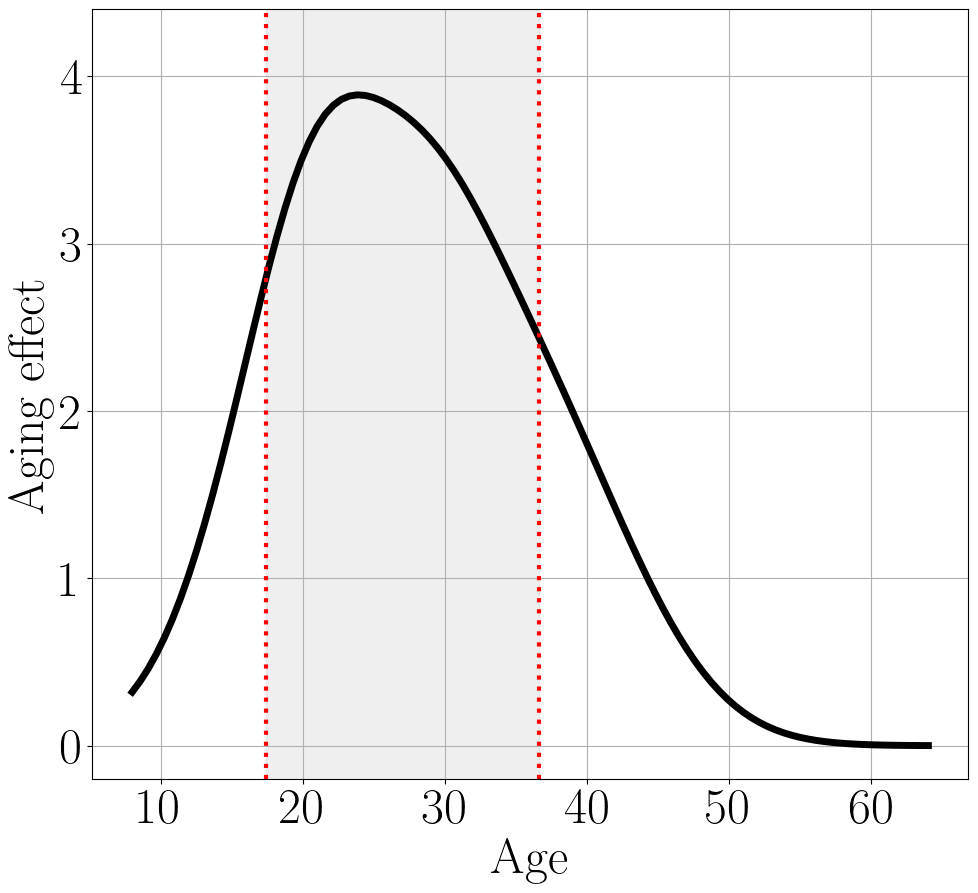

In [21]:
#plot
x = np.linspace(8,64,100)
y = age_effect(x)

fig,ax = plt.subplots(figsize=(11.3,10))
ax.plot(x, y, color = 'black', linewidth = 5)

ax.axvline(x=17.4, color='red', linestyle=':', linewidth = 3)
ax.axvline(x=36.6, color='red', linestyle=':', linewidth = 3)
ax.fill_betweenx(y*100-20, 17.4, 36.6, color='gray', alpha=0.12)

sz = 36
ax.set_xlabel('Age', size = sz)
ax.set_ylabel('Aging effect', size = sz)
ax.set_ylim([-0.2, 4.4])
plt.xticks(size = sz)
plt.yticks(size = sz)

rc('text', usetex=True)
rc('font', family='serif')
plt.grid()

plt.savefig(image_path+'age_effect.pdf')
plt.show()

Ranking (PlusDC)

In [22]:
plusDC_top10 = np.argsort(u_plusDC)[-10:][::-1]
u_t10_plusDC = u_plusDC[plusDC_top10]
for i,index in enumerate(plusDC_top10):
    horse_name = [key for key, value in playerID.items() if value == index][0]
    print(f'top-{i+1}: player: {horse_name}, score: {u_t10_plusDC[i]}')

top-1: player: Roger Federer, score: 3.5691058499232433
top-2: player: Novak Djokovic, score: 3.4647069649356403
top-3: player: Rafael Nadal, score: 3.4399674042385087
top-4: player: Jimmy Connors, score: 3.2625607817700795
top-5: player: Ivan Lendl, score: 3.1400337786296344
top-6: player: Andre Agassi, score: 3.037931149714966
top-7: player: John McEnroe, score: 3.009286957698876
top-8: player: Pete Sampras, score: 2.9596907854884016
top-9: player: Boris Becker, score: 2.8934898015159662
top-10: player: Bjorn Borg, score: 2.8487369205775206


Ranking (BT)

In [38]:
u_BT,v_BT = algorithm.AM(T,X,n,E=1e-6,
        Eu=1e-6,I=30,type = 'pair',P = True,detail=True)

algorithm.pair_likelihood(T,X,u_plusDC,v_plusDC)

u iterative times: 203


-0.6027396281962759

In [ ]:
BT_top10 = np.argsort(u_BT)[-10:][::-1]
u_t10_BT = u_plusDC[BT_top10]
for i,index in enumerate(BT_top10):
    horse_name = [key for key, value in playerID.items() if value == index][0]
    print(f'top-{i+1}: player name:{horse_name}, score:{u_t10_BT[i]}')